<center><h1><span style="color: green;">THỰC HÀNH BUỔI 7</span></h1></center>

# Ví dụ 1

In [67]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

np.random.seed(2)

means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 30
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T

X = np.concatenate((X0, X1), axis = 1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)
# Xbar
X = np.concatenate((np.ones((1, 2*N)), X), axis = 0)

 Hiển thị dữ liệu để quan sát

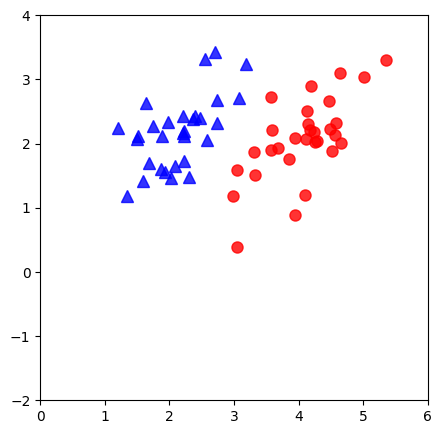

In [68]:
fig, ax = plt.subplots(figsize=(5, 5))

ani = plt.cla()
#plot points
ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
ani = plt.axis([0 , 6, -2, 4])
plt.show()

Xây dựng hàm $y = hw(x) = w0 + w^{T}x = ẅ^{T}ẍ$

In [69]:
# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    return np.sign(np.dot(w.T, x))

Hàm kiểm tra điều kiện dừng

In [70]:
#Stop condition
def has_converged(X, y, w):
    return np.array_equal(h(w, X), y) #True if h(w, X) == y else False

Vòng lặp chính tìm đường phân chia (bộ hệ số W) theo phương pháp Gradient Descent

In [71]:
def perceptron(X, y, w_init):
    w = [w_init]
    N = X.shape[1]
    mis_points = [] # set of miss position points
    while True:
        # mix data
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(3, 1)
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                
                w.append(w_new)

        if has_converged(X, y, w[-1]):
            break
    return (w, mis_points)

Gọi hàm lặp và in ra kết quả là bộ trọng số W ở vòng lặp cuối


In [72]:
d = X.shape[0]
w_init = np.random.randn(d, 1)
(w, m) = perceptron(X, y, w_init)
print(d)
print(w[-1])

3
[[ 13.97858527]
 [-15.02901929]
 [ 14.38743059]]


Xây dựng phương thức vẽ đường phân chia để quan sát kết quả

In [73]:
def draw_line(w):
    w0, w1, w2 = w[0], w[1], w[2]
    if w2 != 0:
        x11, x12 = -100, 100
        return plt.plot([x11, x12], [-(w1*x11 + w0)/w2, -(w1*x12 + w0)/w2], 'k')
    else:
        x10 = -w0/w1
        return plt.plot([x10, x10], [-100, 100], 'k')

Hiển thị kết quả dạng ảnh động (gif) để quan sát sự thay đổi của đường phân chia qua từng bước lặp

MovieWriter imagemagick unavailable; using Pillow instead.


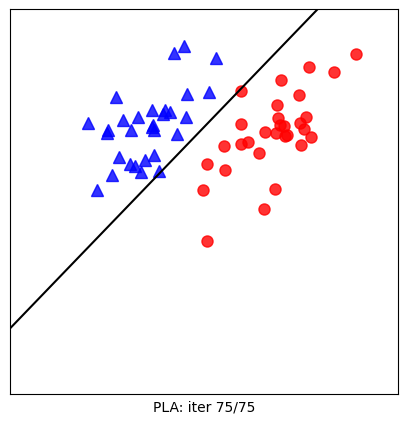

In [74]:
## Visualization
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

def viz_alg_1d_2(w):
    it = len(w)
    fig, ax = plt.subplots(figsize=(5, 5))

    def update(i):
        ani = plt.cla()
        #points
        ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
        ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
        ani = plt.axis([0 , 6, -2, 4])
        i2 = i if i < it else it-1
        ani = draw_line(w[i2])
        if i < it-1:
            # draw one misclassified point
            circle = plt.Circle((X[1, m[i]], X[2, m[i]]), 0.15, color='k', fill = False)
            ax.add_artist(circle)
        # hide axis
        cur_axes = plt.gca()
        cur_axes.axes.get_xaxis().set_ticks([])
        cur_axes.axes.get_yaxis().set_ticks([])
        
        label = 'PLA: iter %d/%d' %(i2, it-1)
        ax.set_xlabel(label)
        return ani, ax

    anim = FuncAnimation(fig, update, frames=np.arange(0, it + 2), interval=1000)
    # save
    anim.save('pla_vis.gif', dpi = 100, writer = 'imagemagick')
    plt.show() 

viz_alg_1d_2(w)

# Ví dụ 2

In [75]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns

main_df = pd.read_csv('sonar.all-data.csv',header=None)
main_df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


Kiểm tra độ cân bằng của dữ liệu bằng cách nhóm theo cột cuối cùng (chỉ số cột là 60 – tính từ không), tức là cột đầu ra y:

<Axes: ylabel='60'>

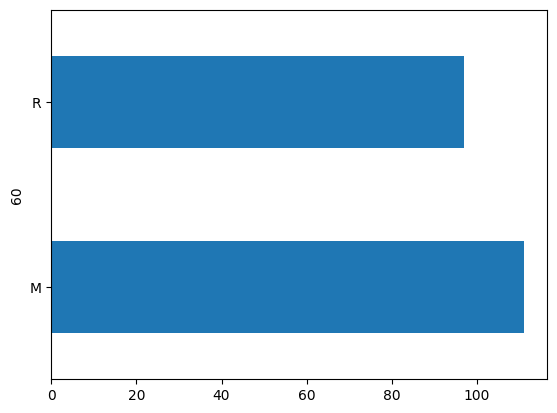

In [76]:
main_df[60].value_counts().plot(kind='barh')

Đoạn chương trình dưới đây đổi nhãn của đầu ra y từ {‘M’, ‘R’} sang {1, -1} (tức là M ứng với class 1;
R ứng với class -1)

In [82]:
y_df = main_df[60]
targes_label = {'M': 1,'R': -1}
targes_df = [targes_label[item] for item in y_df]
print(targes_df)

[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Lấy phần dữ liệu quan sát (bỏ cột 60)

In [78]:
inputs_df = main_df.drop(60, axis=1)

Sau đó bổ sung cột thêm trường dữ liệu x0 = 1 vào bên trái

In [79]:
inputs_df = main_df.drop(60, axis=1)
x0 = np.ones((inputs_df.shape[0], 1))
X = np.concatenate((x0, inputs_df), axis = 1)

Chia dữ liệu

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, targes_df, test_size=0.30,
random_state=42)

#### (a) Sử dụng các hàm đã có ở Ví dụ 1, sau đó huấn luyện mô hình bằng tập dữ liệu X_train, y_train.
**Chú ý chúng ta cần bỏ qua các phần lệnh phục vụ việc hiển thị kết quả dạng hình vẽ.**

Xây dựng hàm $y = hw(x) = w0 + w^{T}x = ẅ^{T}ẍ$

In [89]:
# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    return np.sign(np.dot(w.T, x))

Hàm kiểm tra điều kiện dừng

In [90]:
# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    return np.sign(np.dot(w.T, x))

Vòng lặp chính tìm đường phân chia (bộ hệ số W) theo phương pháp Gradient Descent

In [102]:
# Điều kiện dừng: Kiểm tra nếu không còn điểm nào sai
def has_converged(X, y, w):
    predictions = np.sign(np.dot(X, w))
    return np.all(predictions == y)

# Thuật toán Perceptron (thêm số vòng lặp tối đa)
def perceptron(X, y, w_init, max_iter=1000):
    w = w_init.copy()
    N = X.shape[0]
    for _ in range(max_iter):  # Giới hạn số vòng lặp
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[i].reshape(-1, 1)
            yi = y[i]
            if h(w, xi)[0] != yi:
                w += yi * xi
        if has_converged(X, y, w):
            break
    return w

Gọi hàm lặp và in ra kết quả là bộ trọng số W ở vòng lặp cuối


In [113]:
import time
d = X_train.shape[1]
w_init = np.random.randn(d, 1)
# Huấn luyện mô hình Perceptron
start_time = time.time()
w_final = perceptron(X_train, np.array(y_train).reshape(-1, 1), w_init)
perceptron_time = time.time() - start_time
# print(w_final)

#### (b) Viết bổ sung phần chương trình thực hiện việc chạy test với bộ hệ số đã có và tính độ chính xác bằng accuracy, recall và và precision.

Accuracy của mô hình với Perceptron: 0.7777777777777778
Recall của mô hình với Perceptron: 0.8571428571428571
Precision của mô hình với Perceptron: 0.7692307692307693


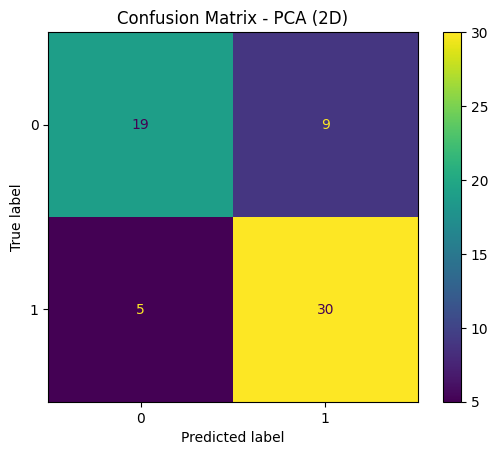

In [110]:
from sklearn.metrics import accuracy_score, recall_score, ConfusionMatrixDisplay, confusion_matrix, precision_score

y_pred_perceptron = np.array([h(w_final, x.reshape(-1, 1))[0] for x in X_test])

# Đánh giá mô hình Perceptron
acc_perceptron = accuracy_score(y_test, y_pred_perceptron)
print("Accuracy của mô hình với Perceptron:", acc_perceptron)
recall_perceptron = recall_score(y_test, y_pred_perceptron)
print("Recall của mô hình với Perceptron:", recall_perceptron)
precision_perceptron = precision_score(y_test, y_pred_perceptron)
print("Precision của mô hình với Perceptron:", precision_perceptron)

# Vẽ confusion matrix cho PCA
cm_pca = confusion_matrix(y_test, y_pred_perceptron)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca)
disp_pca.plot()
plt.title("Confusion Matrix - PCA (2D)")
plt.show()

#### (c) Vẫn phân chia bộ dữ liệu như trong ý trên, sau đó thực nghiệm dự đoán trên các tập với mô hình Logistic và Naïve Bayess

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Huấn luyện và đánh giá mô hình Logistic Regression
logistic = LogisticRegression()
start_time = time.time()
logistic.fit(X_train, y_train)
logistic_time = time.time() - start_time

y_pred_logistic = logistic.predict(X_test)
acc_logistic = accuracy_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)

# Huấn luyện và đánh giá mô hình Naïve Bayes
naive_bayes = GaussianNB()
start_time = time.time()
naive_bayes.fit(X_train, y_train)
nb_time = time.time() - start_time

y_pred_nb = naive_bayes.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)

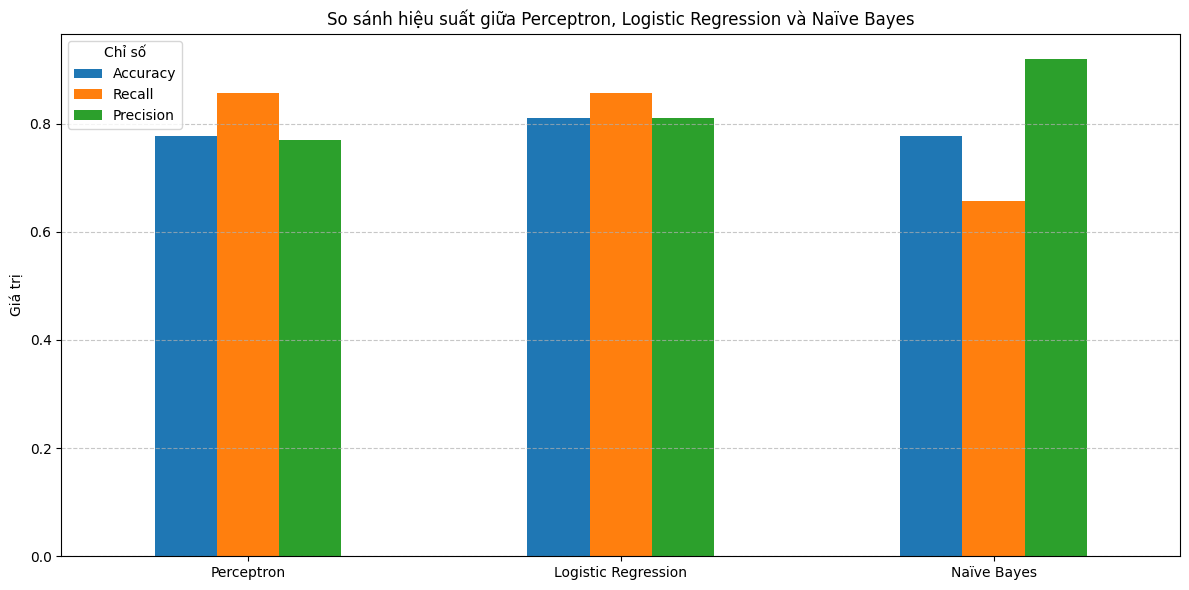

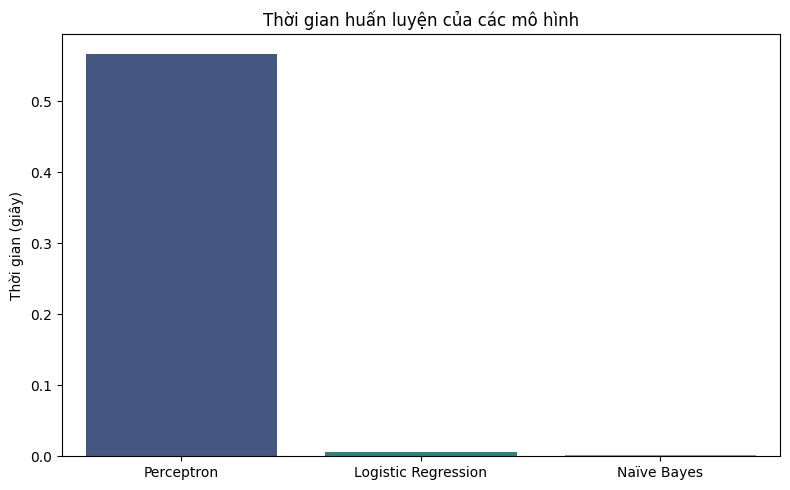

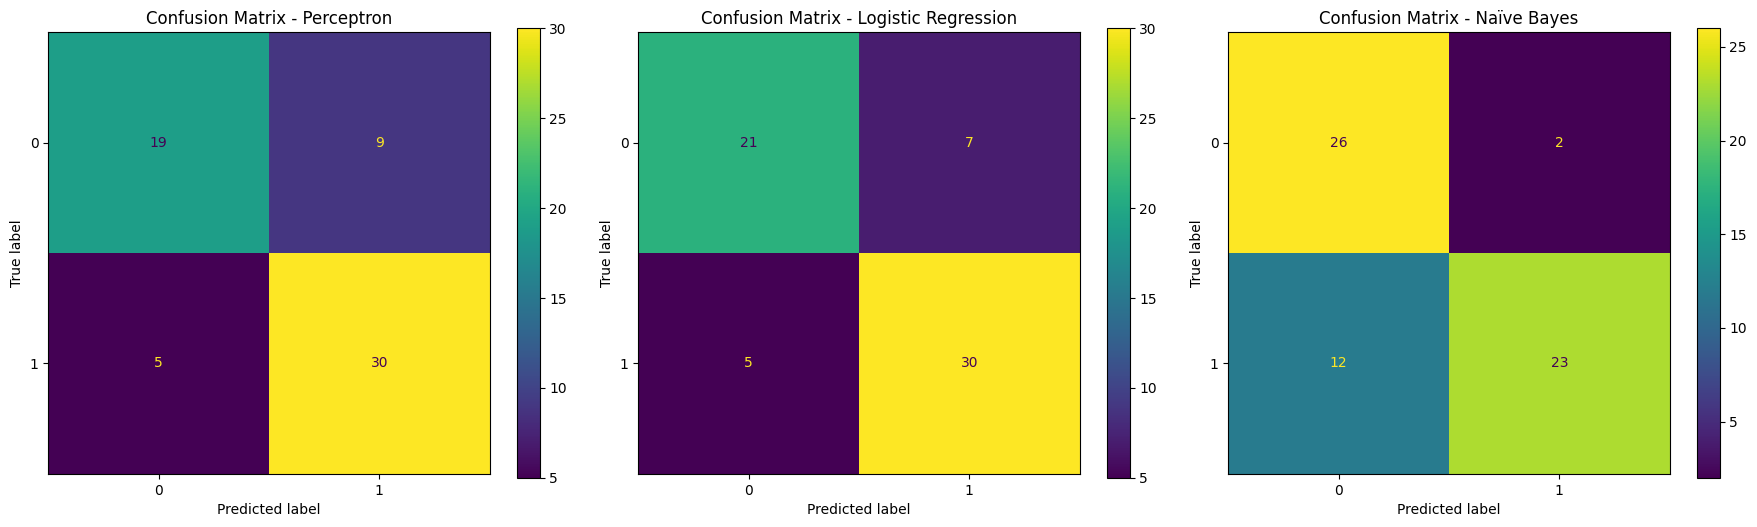

Perceptron:
Accuracy: 0.7778, Recall: 0.8571, Precision: 0.7692, Time: 0.5668s
Logistic Regression:
Accuracy: 0.8095, Recall: 0.8571, Precision: 0.8108, Time: 0.0059s
Naïve Bayes:
Accuracy: 0.7778, Recall: 0.6571, Precision: 0.9200, Time: 0.0012s


In [117]:

models = ['Perceptron', 'Logistic Regression', 'Naïve Bayes']
metrics = {
    'Accuracy': [acc_perceptron, acc_logistic, acc_nb],
    'Recall': [recall_perceptron, recall_logistic, recall_nb],
    'Precision': [precision_perceptron, precision_logistic, precision_nb],
    'Training Time (s)': [perceptron_time, logistic_time, nb_time]
}

# Tạo DataFrame để trực quan hóa
df_metrics = pd.DataFrame(metrics, index=models)

# Biểu đồ cột so sánh các chỉ số
plt.figure(figsize=(12, 6))
df_metrics[['Accuracy', 'Recall', 'Precision']].plot(kind='bar', ax=plt.gca())
plt.title('So sánh hiệu suất giữa Perceptron, Logistic Regression và Naïve Bayes')
plt.ylabel('Giá trị')
plt.xticks(rotation=0)
plt.legend(title='Chỉ số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Biểu đồ cột thời gian huấn luyện
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=[perceptron_time, logistic_time, nb_time], hue=models, palette='viridis', legend=False)
plt.title('Thời gian huấn luyện của các mô hình')
plt.ylabel('Thời gian (giây)')
plt.tight_layout()
plt.show()

# Vẽ Confusion Matrix cho từng mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_pred, title in zip(axes, [y_pred_perceptron, y_pred_logistic, y_pred_nb], models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(f"Confusion Matrix - {title}")
plt.tight_layout()
plt.show()

# In kết quả
print("Perceptron:")
print(f"Accuracy: {acc_perceptron:.4f}, Recall: {recall_perceptron:.4f}, Precision: {precision_perceptron:.4f}, Time: {perceptron_time:.4f}s")
print("Logistic Regression:")
print(f"Accuracy: {acc_logistic:.4f}, Recall: {recall_logistic:.4f}, Precision: {precision_logistic:.4f}, Time: {logistic_time:.4f}s")
print("Naïve Bayes:")
print(f"Accuracy: {acc_nb:.4f}, Recall: {recall_nb:.4f}, Precision: {precision_nb:.4f}, Time: {nb_time:.4f}s")

## Ví dụ 3

In [120]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Tải dữ liệu breast cancer
cancer_data = datasets.load_breast_cancer()
print("Dữ liệu mẫu thứ 5:", cancer_data.data[5])

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(cancer_data.data, cancer_data.target, test_size=0.3, random_state=109)

Dữ liệu mẫu thứ 5: [1.245e+01 1.570e+01 8.257e+01 4.771e+02 1.278e-01 1.700e-01 1.578e-01
 8.089e-02 2.087e-01 7.613e-02 3.345e-01 8.902e-01 2.217e+00 2.719e+01
 7.510e-03 3.345e-02 3.672e-02 1.137e-02 2.165e-02 5.082e-03 1.547e+01
 2.375e+01 1.034e+02 7.416e+02 1.791e-01 5.249e-01 5.355e-01 1.741e-01
 3.985e-01 1.244e-01]


--- Yêu cầu 1: Giảm chiều về 2 chiều bằng PCA ---

In [121]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(cancer_data.data)  # Giảm chiều toàn bộ dữ liệu để trực quan hóa

--- Yêu cầu 2: Hiển thị dữ liệu đã giảm chiều với 2 màu ---

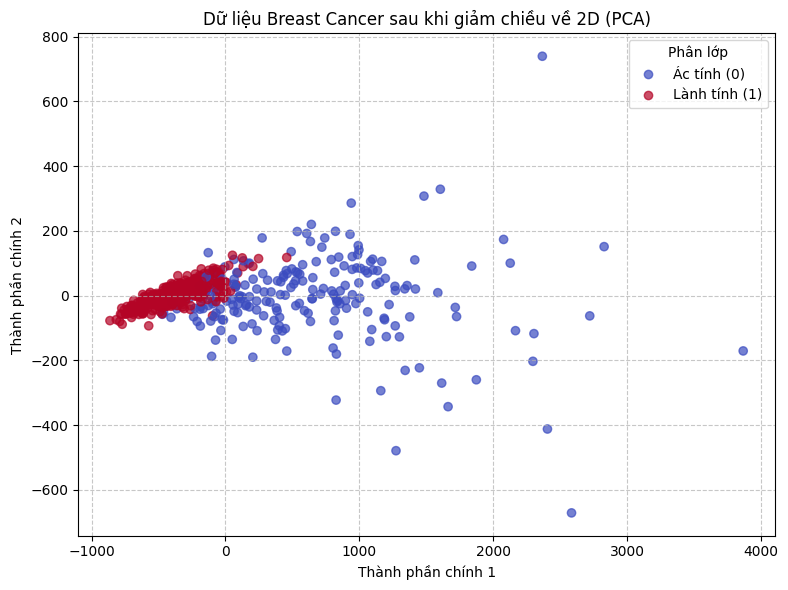

In [122]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cancer_data.target, cmap='coolwarm', alpha=0.7)
plt.title('Dữ liệu Breast Cancer sau khi giảm chiều về 2D (PCA)')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Ác tính (0)', 'Lành tính (1)'], title='Phân lớp')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Yêu cầu 3: Phân loại bằng Logistic Regression và Perceptron ---

In [123]:
# Thêm cột bias vào dữ liệu cho Perceptron
x0_train = np.ones((X_train.shape[0], 1))
x0_test = np.ones((X_test.shape[0], 1))
X_train_perceptron = np.concatenate((x0_train, X_train), axis=1)
X_test_perceptron = np.concatenate((x0_test, X_test), axis=1)

# Chuyển nhãn về {-1, 1} cho Perceptron
y_train_perceptron = np.where(y_train == 0, -1, 1)
y_test_perceptron = np.where(y_test == 0, -1, 1)

# Hàm Perceptron
def h(w, x):
    return np.sign(np.dot(w.T, x))
def has_converged(X, y, w):
    return np.array_equal(h(w, X), y)

def perceptron(X, y, w_init, max_iter=1000):
    w = [w_init]
    N = X.shape[1]
    mis_points = []
    iter_count = 0
    while iter_count < max_iter:
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(X.shape[0], 1)
            yi = y[mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi * xi
                w.append(w_new)
        if has_converged(X, y, w[-1]):
            break
        iter_count += 1
    return (w, mis_points)

# Huấn luyện Perceptron
d = X_train_perceptron.shape[1]  # Số chiều (31: 30 đặc trưng + 1 bias)
w_init = np.random.randn(d, 1)
start_time = time.time()
(w, m) = perceptron(X_train_perceptron.T, y_train_perceptron, w_init)
perceptron_time = time.time() - start_time
w_final = w[-1]

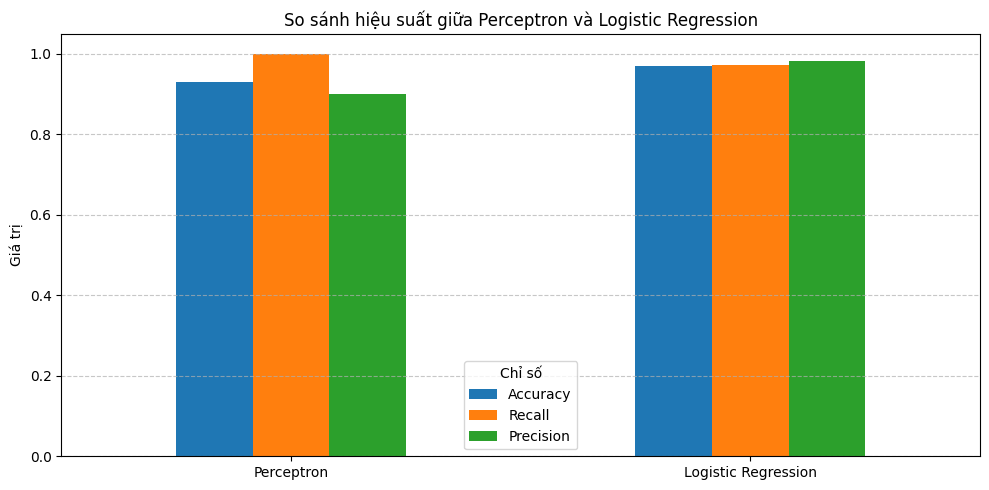

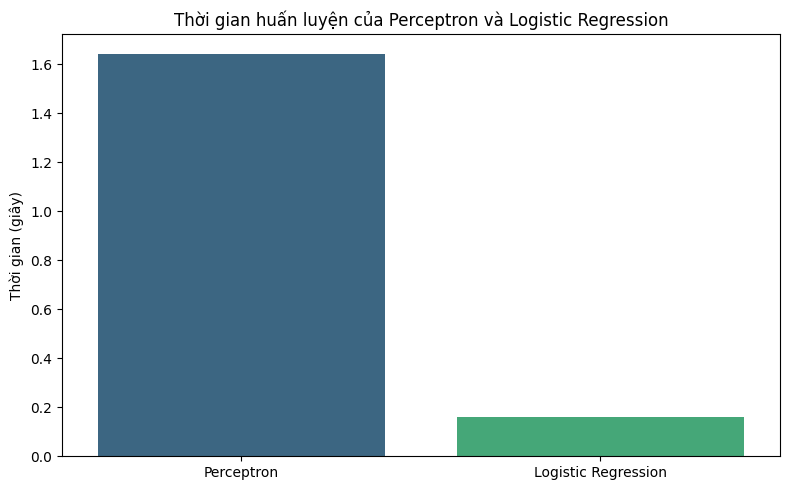

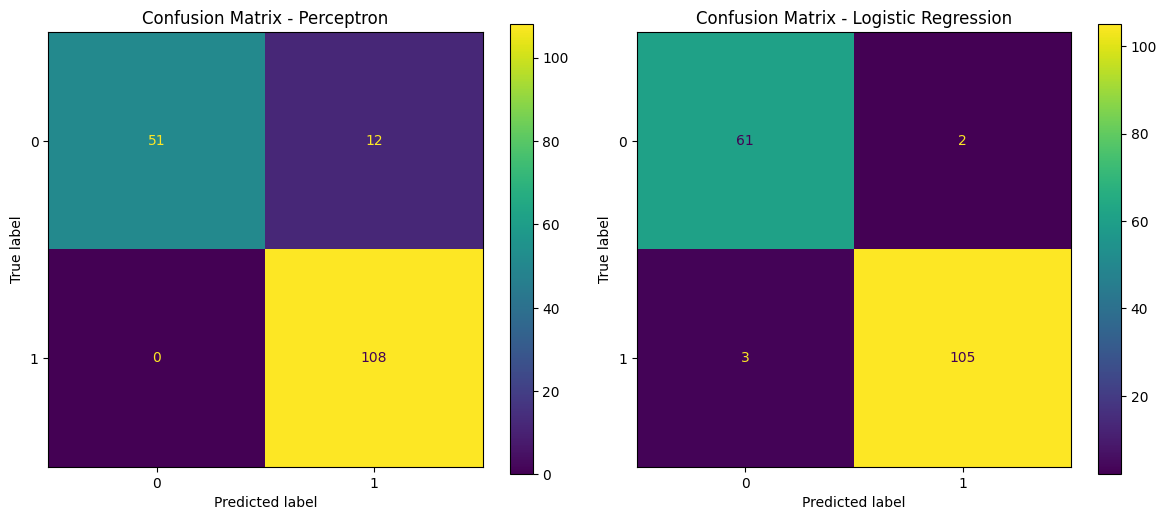

Perceptron:
Accuracy: 0.9298, Recall: 1.0000, Precision: 0.9000, Time: 1.6422s
Logistic Regression:
Accuracy: 0.9708, Recall: 0.9722, Precision: 0.9813, Time: 0.1619s


In [124]:
# Dự đoán và đánh giá Perceptron
y_pred_perceptron = np.array([h(w_final, x.reshape(-1, 1))[0] for x in X_test_perceptron])
acc_perceptron = accuracy_score(y_test_perceptron, y_pred_perceptron)
recall_perceptron = recall_score(y_test_perceptron, y_pred_perceptron)
precision_perceptron = precision_score(y_test_perceptron, y_pred_perceptron)

# Huấn luyện Logistic Regression
logistic = LogisticRegression(max_iter=1000)
start_time = time.time()
logistic.fit(X_train, y_train)
logistic_time = time.time() - start_time

y_pred_logistic = logistic.predict(X_test)
acc_logistic = accuracy_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)

# --- Trực quan hóa so sánh ---
models = ['Perceptron', 'Logistic Regression']
metrics = {
    'Accuracy': [acc_perceptron, acc_logistic],
    'Recall': [recall_perceptron, recall_logistic],
    'Precision': [precision_perceptron, precision_logistic],
    'Training Time (s)': [perceptron_time, logistic_time]
}

# Tạo DataFrame để trực quan hóa
df_metrics = pd.DataFrame(metrics, index=models)

# Biểu đồ cột so sánh các chỉ số
plt.figure(figsize=(10, 5))
df_metrics[['Accuracy', 'Recall', 'Precision']].plot(kind='bar', ax=plt.gca())
plt.title('So sánh hiệu suất giữa Perceptron và Logistic Regression')
plt.ylabel('Giá trị')
plt.xticks(rotation=0)
plt.legend(title='Chỉ số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Biểu đồ cột thời gian huấn luyện
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=[perceptron_time, logistic_time], hue=models, palette='viridis', legend=False)
plt.title('Thời gian huấn luyện của Perceptron và Logistic Regression')
plt.ylabel('Thời gian (giây)')
plt.tight_layout()
plt.show()

# Vẽ Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(axes, [y_pred_perceptron, y_pred_logistic], models):
    cm = confusion_matrix(y_test_perceptron if title == 'Perceptron' else y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(f"Confusion Matrix - {title}")
plt.tight_layout()
plt.show()

# In kết quả
print("Perceptron:")
print(f"Accuracy: {acc_perceptron:.4f}, Recall: {recall_perceptron:.4f}, Precision: {precision_perceptron:.4f}, Time: {perceptron_time:.4f}s")
print("Logistic Regression:")
print(f"Accuracy: {acc_logistic:.4f}, Recall: {recall_logistic:.4f}, Precision: {precision_logistic:.4f}, Time: {logistic_time:.4f}s")

## Ví dụ 4 (Bài tập tự thực hành)

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import time

# Đọc dữ liệu
df = pd.read_csv("framingham.csv")
print(df.head())

# --- Xử lý dữ liệu sơ bộ ---
# Điền giá trị thiếu bằng trung bình cột
df.fillna(df.mean(), inplace=True)

# Tách đặc trưng và nhãn
X = df.drop('TenYearCHD', axis=1).values
y = df['TenYearCHD'].values

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

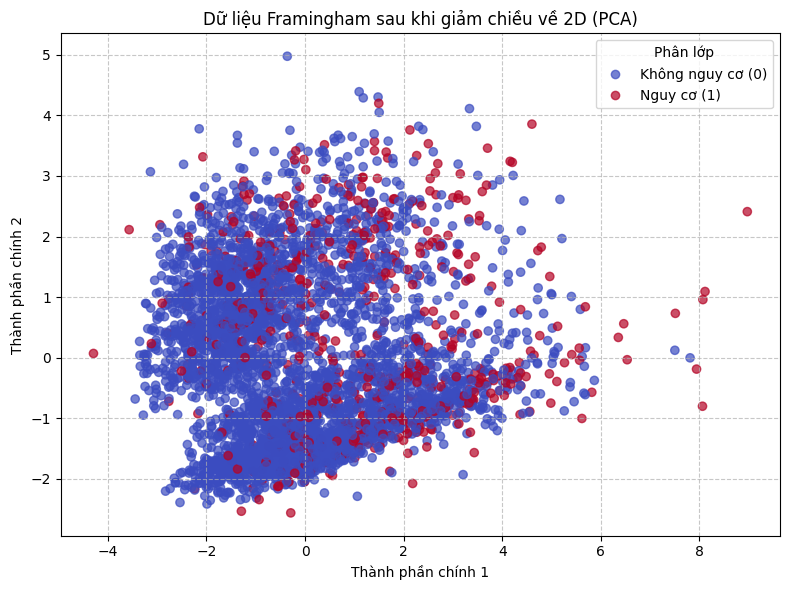

In [126]:
# --- Yêu cầu 1: Giảm chiều dữ liệu về 2 chiều và trực quan hóa ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Trực quan hóa dữ liệu đã giảm chiều
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dữ liệu Framingham sau khi giảm chiều về 2D (PCA)')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Không nguy cơ (0)', 'Nguy cơ (1)'], title='Phân lớp')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [127]:
# --- Yêu cầu 2: Phân loại trên dữ liệu gốc ---
# Chia dữ liệu thành tập huấn luyện và kiểm tra (7:3)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Thêm cột bias cho Perceptron
x0_train = np.ones((X_train.shape[0], 1))
x0_test = np.ones((X_test.shape[0], 1))
X_train_perceptron = np.concatenate((x0_train, X_train), axis=1)
X_test_perceptron = np.concatenate((x0_test, X_test), axis=1)

# Chuyển nhãn về {-1, 1} cho Perceptron
y_train_perceptron = np.where(y_train == 0, -1, 1)
y_test_perceptron = np.where(y_test == 0, -1, 1)

# Hàm Perceptron
def h(w, x):
    return np.sign(np.dot(w.T, x))

def has_converged(X, y, w):
    return np.array_equal(h(w, X), y)

def perceptron(X, y, w_init, max_iter=1000):
    w = [w_init]
    N = X.shape[1]
    mis_points = []
    iter_count = 0
    while iter_count < max_iter:
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(X.shape[0], 1)
            yi = y[mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi * xi
                w.append(w_new)
        if has_converged(X, y, w[-1]):
            break
        iter_count += 1
    return (w, mis_points)

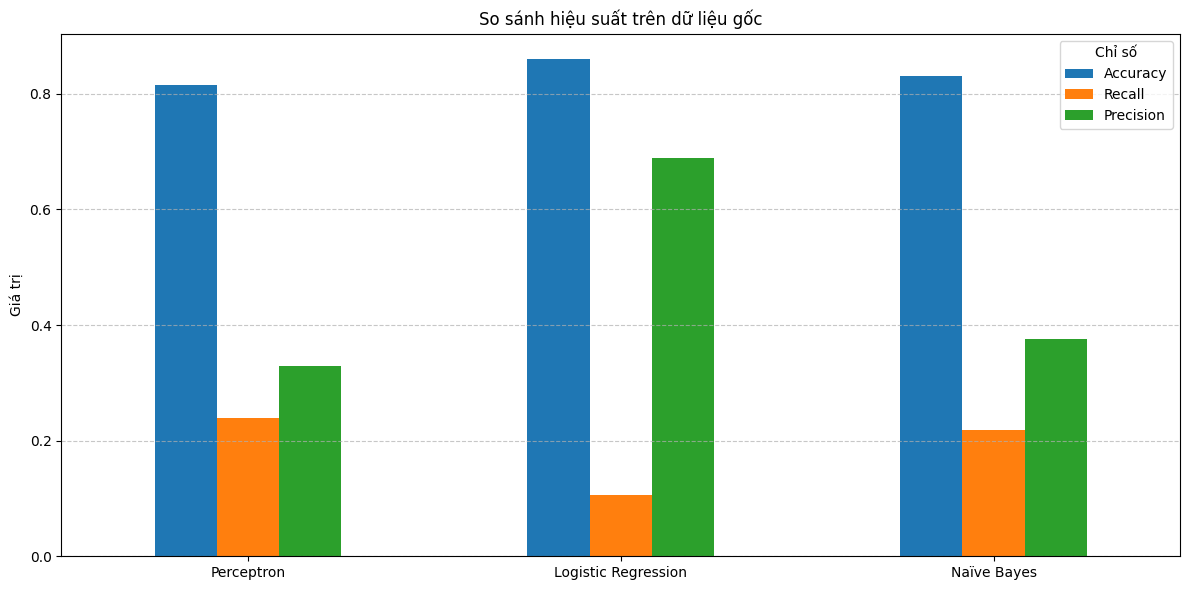

In [128]:
# 2a. Perceptron
d = X_train_perceptron.shape[1]
w_init = np.random.randn(d, 1)
start_time = time.time()
(w, m) = perceptron(X_train_perceptron.T, y_train_perceptron, w_init)
perceptron_time = time.time() - start_time
w_final = w[-1]

y_pred_perceptron = np.array([h(w_final, x.reshape(-1, 1))[0] for x in X_test_perceptron])
acc_perceptron = accuracy_score(y_test_perceptron, y_pred_perceptron)
recall_perceptron = recall_score(y_test_perceptron, y_pred_perceptron)
precision_perceptron = precision_score(y_test_perceptron, y_pred_perceptron)

# 2b. Logistic Regression
logistic = LogisticRegression(max_iter=1000)
start_time = time.time()
logistic.fit(X_train, y_train)
logistic_time = time.time() - start_time

y_pred_logistic = logistic.predict(X_test)
acc_logistic = accuracy_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)

# 2c. Naïve Bayes (GaussianNB vì dữ liệu liên tục)
naive_bayes = GaussianNB()
start_time = time.time()
naive_bayes.fit(X_train, y_train)
nb_time = time.time() - start_time

y_pred_nb = naive_bayes.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)

# So sánh hiệu suất trên dữ liệu gốc
models = ['Perceptron', 'Logistic Regression', 'Naïve Bayes']
metrics = {
    'Accuracy': [acc_perceptron, acc_logistic, acc_nb],
    'Recall': [recall_perceptron, recall_logistic, recall_nb],
    'Precision': [precision_perceptron, precision_logistic, precision_nb],
    'Training Time (s)': [perceptron_time, logistic_time, nb_time]
}

df_metrics = pd.DataFrame(metrics, index=models)
plt.figure(figsize=(12, 6))
df_metrics[['Accuracy', 'Recall', 'Precision']].plot(kind='bar', ax=plt.gca())
plt.title('So sánh hiệu suất trên dữ liệu gốc')
plt.ylabel('Giá trị')
plt.xticks(rotation=0)
plt.legend(title='Chỉ số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

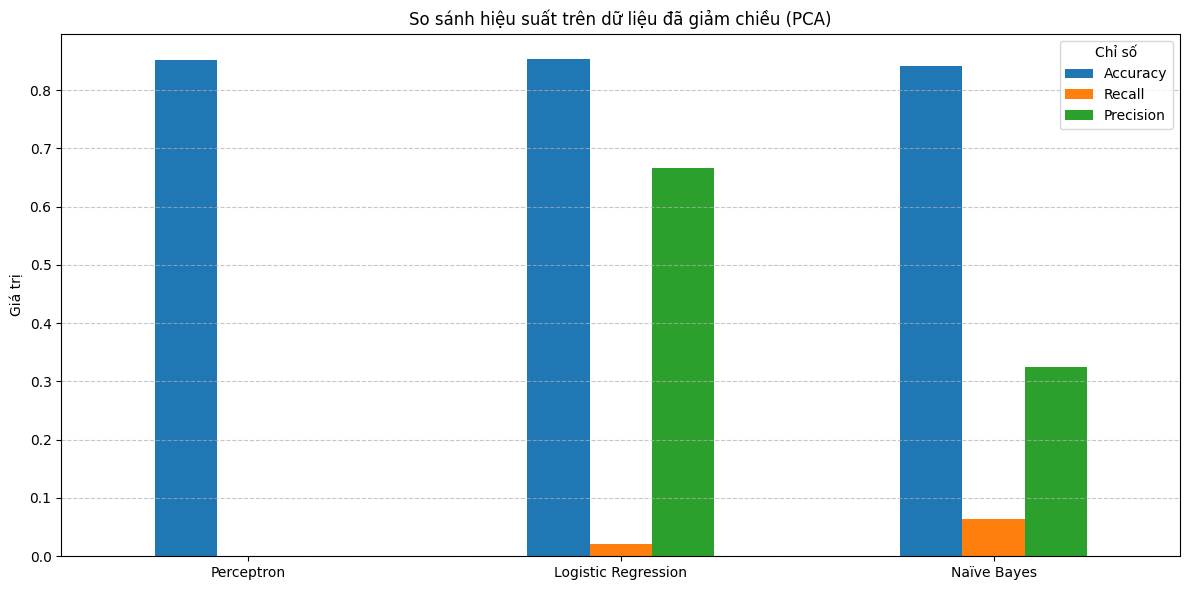


--- Kết quả trên dữ liệu gốc ---
Perceptron:
Accuracy: 0.8153, Recall: 0.2394, Precision: 0.3285
Logistic Regression:
Accuracy: 0.8608, Recall: 0.1064, Precision: 0.6897
Naïve Bayes:
Accuracy: 0.8310, Recall: 0.2181, Precision: 0.3761

--- Kết quả trên dữ liệu đã giảm chiều (PCA) ---
Perceptron:
Accuracy: 0.8522, Recall: 0.0000, Precision: 0.0000
Logistic Regression:
Accuracy: 0.8538, Recall: 0.0213, Precision: 0.6667
Naïve Bayes:
Accuracy: 0.8420, Recall: 0.0638, Precision: 0.3243


In [129]:
# --- Yêu cầu 3: Phân loại trên dữ liệu đã giảm chiều ---
# Chia dữ liệu đã giảm chiều
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Thêm cột bias cho Perceptron
x0_train_pca = np.ones((X_train_pca.shape[0], 1))
x0_test_pca = np.ones((X_test_pca.shape[0], 1))
X_train_pca_perceptron = np.concatenate((x0_train_pca, X_train_pca), axis=1)
X_test_pca_perceptron = np.concatenate((x0_test_pca, X_test_pca), axis=1)

# Chuyển nhãn về {-1, 1} cho Perceptron
y_train_pca_perceptron = np.where(y_train_pca == 0, -1, 1)
y_test_pca_perceptron = np.where(y_test_pca == 0, -1, 1)

# Perceptron trên dữ liệu PCA
d_pca = X_train_pca_perceptron.shape[1]
w_init_pca = np.random.randn(d_pca, 1)
start_time = time.time()
(w_pca, m_pca) = perceptron(X_train_pca_perceptron.T, y_train_pca_perceptron, w_init_pca)
perceptron_time_pca = time.time() - start_time
w_final_pca = w_pca[-1]

y_pred_perceptron_pca = np.array([h(w_final_pca, x.reshape(-1, 1))[0] for x in X_test_pca_perceptron])
acc_perceptron_pca = accuracy_score(y_test_pca_perceptron, y_pred_perceptron_pca)
recall_perceptron_pca = recall_score(y_test_pca_perceptron, y_pred_perceptron_pca)
precision_perceptron_pca = precision_score(y_test_pca_perceptron, y_pred_perceptron_pca)

# Logistic Regression trên dữ liệu PCA
logistic_pca = LogisticRegression(max_iter=1000)
start_time = time.time()
logistic_pca.fit(X_train_pca, y_train_pca)
logistic_time_pca = time.time() - start_time

y_pred_logistic_pca = logistic_pca.predict(X_test_pca)
acc_logistic_pca = accuracy_score(y_test_pca, y_pred_logistic_pca)
recall_logistic_pca = recall_score(y_test_pca, y_pred_logistic_pca)
precision_logistic_pca = precision_score(y_test_pca, y_pred_logistic_pca)

# Naïve Bayes trên dữ liệu PCA
naive_bayes_pca = GaussianNB()
start_time = time.time()
naive_bayes_pca.fit(X_train_pca, y_train_pca)
nb_time_pca = time.time() - start_time

y_pred_nb_pca = naive_bayes_pca.predict(X_test_pca)
acc_nb_pca = accuracy_score(y_test_pca, y_pred_nb_pca)
recall_nb_pca = recall_score(y_test_pca, y_pred_nb_pca)
precision_nb_pca = precision_score(y_test_pca, y_pred_nb_pca)

# So sánh hiệu suất trên dữ liệu PCA
metrics_pca = {
    'Accuracy': [acc_perceptron_pca, acc_logistic_pca, acc_nb_pca],
    'Recall': [recall_perceptron_pca, recall_logistic_pca, recall_nb_pca],
    'Precision': [precision_perceptron_pca, precision_logistic_pca, precision_nb_pca],
    'Training Time (s)': [perceptron_time_pca, logistic_time_pca, nb_time_pca]
}

df_metrics_pca = pd.DataFrame(metrics_pca, index=models)
plt.figure(figsize=(12, 6))
df_metrics_pca[['Accuracy', 'Recall', 'Precision']].plot(kind='bar', ax=plt.gca())
plt.title('So sánh hiệu suất trên dữ liệu đã giảm chiều (PCA)')
plt.ylabel('Giá trị')
plt.xticks(rotation=0)
plt.legend(title='Chỉ số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# In kết quả
print("\n--- Kết quả trên dữ liệu gốc ---")
print("Perceptron:")
print(f"Accuracy: {acc_perceptron:.4f}, Recall: {recall_perceptron:.4f}, Precision: {precision_perceptron:.4f}")
print("Logistic Regression:")
print(f"Accuracy: {acc_logistic:.4f}, Recall: {recall_logistic:.4f}, Precision: {precision_logistic:.4f}")
print("Naïve Bayes:")
print(f"Accuracy: {acc_nb:.4f}, Recall: {recall_nb:.4f}, Precision: {precision_nb:.4f}")

print("\n--- Kết quả trên dữ liệu đã giảm chiều (PCA) ---")
print("Perceptron:")
print(f"Accuracy: {acc_perceptron_pca:.4f}, Recall: {recall_perceptron_pca:.4f}, Precision: {precision_perceptron_pca:.4f}")
print("Logistic Regression:")
print(f"Accuracy: {acc_logistic_pca:.4f}, Recall: {recall_logistic_pca:.4f}, Precision: {precision_logistic_pca:.4f}")
print("Naïve Bayes:")
print(f"Accuracy: {acc_nb_pca:.4f}, Recall: {recall_nb_pca:.4f}, Precision: {precision_nb_pca:.4f}")

## Ví dụ 5

   CustomerID  Shopping Basket  Gender  Age         Store Type  \
0    20358063            48.81    Male   26  Convenient Stores   
1    24635139            33.44  Female   33         Superstore   
2    27584479           131.57    Male   56             Online   
3    28008212            20.02    Male   27  Convenient Stores   
4    29130973            95.54  Female   55             Online   

   Value Products  Brand Products  Top Fresco Products  
0               8               2                    1  
1               6               5                    1  
2              35               8                   12  
3               0               1                    1  
4              38              18                   20  

--- Yêu cầu 1: Hồi quy tuyến tính ---
Mean Squared Error (MSE): 295.9983609515469
R-squared (R2): 0.841926445691964
Hệ số của mô hình: [-2.61195353  0.07822874  8.71253319  0.99442134  1.03395133  2.44239648]
Hệ số chặn (intercept): 7.667342298275258


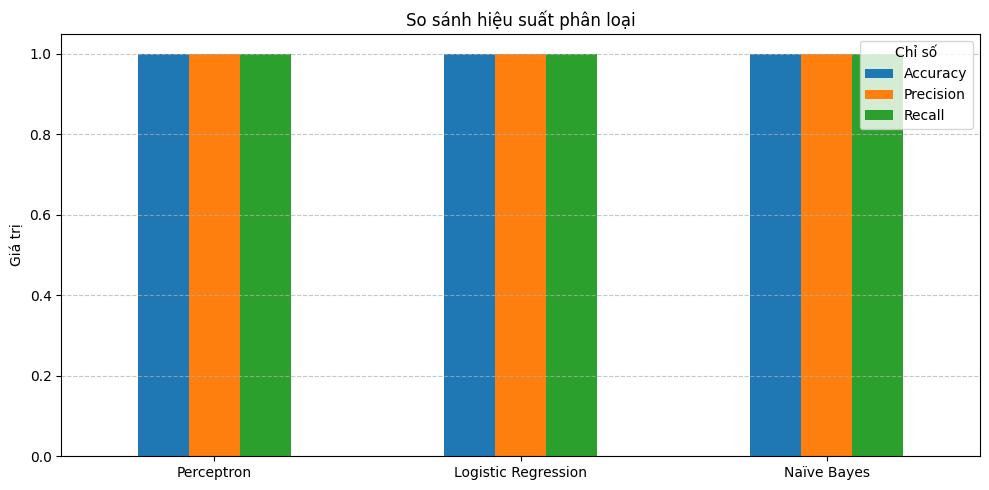


--- Yêu cầu 2: Phân loại ---
Perceptron:
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000
Hệ số của Perceptron: [[-1886.37850822     9.98035419   -18.79478693   966.038051
    117.82657138   179.11959512   -11.98806485]]

Logistic Regression:
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000
Hệ số của Logistic Regression: [[ 0.27493706  0.09229302  0.95184175  0.33188493  0.54348448 -0.07898914]]

Naïve Bayes:
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000


In [130]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("Analysis-Portfolio-Task-Data.csv")
print(df.head())

# --- Yêu cầu 1: Chuẩn hóa dữ liệu và hồi quy tuyến tính ---

# Chuẩn hóa dữ liệu
# Loại bỏ cột CustomerID
df = df.drop('CustomerID', axis=1)

# Chuyển Gender thành số: Male=1, Female=0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Chuyển Store Type thành số: Convenient Stores=0, Superstore=1, Online=2
df['Store Type'] = df['Store Type'].map({'Convenient Stores': 0, 'Superstore': 1, 'Online': 2})

# Tách đặc trưng và nhãn
X = df.drop('Shopping Basket', axis=1).values
y = df['Shopping Basket'].values

# Chia dữ liệu: 60 bản ghi đầu là training, 15 bản ghi cuối là validation
X_train = X[:60]
X_test = X[60:]
y_train = y[:60]
y_test = y[60:]

# Hồi quy tuyến tính
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Dự đoán trên tập validation
y_pred = lin_reg.predict(X_test)

# Đánh giá mô hình
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# In kết quả
print("\n--- Yêu cầu 1: Hồi quy tuyến tính ---")
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)
print("Hệ số của mô hình:", lin_reg.coef_)
print("Hệ số chặn (intercept):", lin_reg.intercept_)

# --- Yêu cầu 2: Phân loại ---

# Chuyển Shopping Basket thành nhãn phân loại: >50 là 1, <=50 là -1 (cho Perceptron) hoặc 0 (cho Logistic và NB)
y_class = np.where(df['Shopping Basket'] > 50, 1, -1)
y_class_logistic_nb = np.where(df['Shopping Basket'] > 50, 1, 0)  # Logistic và NB dùng nhãn 0/1

# Chia dữ liệu phân loại
y_train_class = y_class[:60]
y_test_class = y_class[60:]
y_train_class_logistic_nb = y_class_logistic_nb[:60]
y_test_class_logistic_nb = y_class_logistic_nb[60:]

# Thêm cột bias cho Perceptron
x0_train = np.ones((X_train.shape[0], 1))
x0_test = np.ones((X_test.shape[0], 1))
X_train_perceptron = np.concatenate((x0_train, X_train), axis=1)
X_test_perceptron = np.concatenate((x0_test, X_test), axis=1)

# 2a. Perceptron
def h(w, x):
    return np.sign(np.dot(w.T, x))

def has_converged(X, y, w):
    return np.array_equal(h(w, X), y)

def perceptron(X, y, w_init, max_iter=1000):
    w = [w_init]
    N = X.shape[1]
    mis_points = []
    iter_count = 0
    while iter_count < max_iter:
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(X.shape[0], 1)
            yi = y[mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi * xi
                w.append(w_new)
        if has_converged(X, y, w[-1]):
            break
        iter_count += 1
    return (w, mis_points)

d = X_train_perceptron.shape[1]
w_init = np.random.randn(d, 1)
(w, m) = perceptron(X_train_perceptron.T, y_train_class, w_init)
w_final = w[-1]

y_pred_perceptron = np.array([h(w_final, x.reshape(-1, 1))[0] for x in X_test_perceptron])
acc_perceptron = accuracy_score(y_test_class, y_pred_perceptron)
precision_perceptron = precision_score(y_test_class, y_pred_perceptron)
recall_perceptron = recall_score(y_test_class, y_pred_perceptron)

# 2b. Logistic Regression
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train, y_train_class_logistic_nb)

y_pred_logistic = logistic.predict(X_test)
acc_logistic = accuracy_score(y_test_class_logistic_nb, y_pred_logistic)
precision_logistic = precision_score(y_test_class_logistic_nb, y_pred_logistic)
recall_logistic = recall_score(y_test_class_logistic_nb, y_pred_logistic)

# 2c. Naïve Bayes
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train_class_logistic_nb)

y_pred_nb = naive_bayes.predict(X_test)
acc_nb = accuracy_score(y_test_class_logistic_nb, y_pred_nb)
precision_nb = precision_score(y_test_class_logistic_nb, y_pred_nb)
recall_nb = recall_score(y_test_class_logistic_nb, y_pred_nb)

# So sánh các mô hình phân loại
models = ['Perceptron', 'Logistic Regression', 'Naïve Bayes']
metrics = {
    'Accuracy': [acc_perceptron, acc_logistic, acc_nb],
    'Precision': [precision_perceptron, precision_logistic, precision_nb],
    'Recall': [recall_perceptron, recall_logistic, recall_nb]
}

df_metrics = pd.DataFrame(metrics, index=models)
plt.figure(figsize=(10, 5))
df_metrics.plot(kind='bar', ax=plt.gca())
plt.title('So sánh hiệu suất phân loại')
plt.ylabel('Giá trị')
plt.xticks(rotation=0)
plt.legend(title='Chỉ số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# In kết quả phân loại
print("\n--- Yêu cầu 2: Phân loại ---")
print("Perceptron:")
print(f"Accuracy: {acc_perceptron:.4f}, Precision: {precision_perceptron:.4f}, Recall: {recall_perceptron:.4f}")
print("Hệ số của Perceptron:", w_final.T)

print("\nLogistic Regression:")
print(f"Accuracy: {acc_logistic:.4f}, Precision: {precision_logistic:.4f}, Recall: {recall_logistic:.4f}")
print("Hệ số của Logistic Regression:", logistic.coef_)

print("\nNaïve Bayes:")
print(f"Accuracy: {acc_nb:.4f}, Precision: {precision_nb:.4f}, Recall: {recall_nb:.4f}")